### Introdução a processamento de sinais
---
Os sinais que geralmente encontramos na natureza são sinais analógicos e em tempo contínuo, esses sinais são representações fisícas que por conveniência podemos querer representar em sinais elétricos (digitais). Pois sinais analógicos contém um números infinitos de pontos não são apropriados para serem processados, pois requer infinita quantidade de memorias e poder de processamento. Para processar esse sinal digitalmente precisamos converter esse sinal para um formato digital, conversão A/D.

+ __Amostragem:__ Processo de aquisição de amostras para ter uma maior precisão no formato da onda a ser estudada. A amostragem converte um sinal analógico em uma série de impulsos.

O teorema de Nyquist nos diz que para um sinal digital ser funcionalmente igual ao sinal analógico original, a frequência da amostragem precisa ser no mínimo duas vezes maior que a frequência do sinal analógico.

+ __Conversão:__ Converte a saída da amostragem e a retenção de uma série de códigos binários que representam a amplitude do sinal analógico.

+ __Quantização:__ Onde é convertido cada valor da amostragem do sinal analógico em um conjunto de valores discretos, ou seja, em código bináro. Quanto maior for os números de bits, mais precisa será a representação.

> __Conversão A/D:__
> + __Número de bits:__ $Nb = 4$
> + __Calcular o Passo de Quantização:__ $k = \frac{V_pp}{2^{Nb}}$
> + __Valor Quantizado:__ $vq = \frac{Sinal}{k}$

O teorema da amostragem garante que um sinal analógico pode, em teoria, ser perfeitamente recuperado, desde que
como a taxa de amostragem é pelo menos duas vezes o componente de frequência mais alta do sinal analógico a ser
amostrado. A condição é descrita como:
$$f_s \geq f_{max}$$

Quando está condição não está satisfeita dizemos que ocorreu *aliasing*, para resolver esse problema podemos usar um filtro passa-baixa a ser aplicado antes da amostragem. Um sinal amostrado $Xs(t)$ pode ser obtido pela amostragem do sinal contínuo $x(t)$ a uma taxa de amostragem $f_s$ por segundo, esse processo pode ser escrito matematicamente por:
$$Xs(t) = x(t) . p(t)$$
onde $p(t)$ é o trem de pulsos com período $T = \frac{1}{fs}$, expresso por:
$$p(t) = \sum_{n = - ∞}^{∞} δ(t - nT)$$   

In [ ]:
#import cupy as cp
import numpy as np
import scipy.signal as signal
import scipy.fft
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

In [ ]:
def biquant(nb, vp_min, vp_max, x):

    L = 2**nb
    k = (vp_max - vp_min)/L

    vq = round((x - vp_min)/k)
    xq = vp_min + vq*k
    #xq = round((x/k)*k)

    return xq

tx = 8000
T = 1/tx

t = np.arange(0, 0.02, T)
sig = lambda t: 3 * np.sin(2 * np.pi * 100 * t)

qsig = list()
bits = 2
for i in range(len(t)):
    qsig.append(biquant(bits, -3, 3, sig(t[i])))

# Calculando o erro.
erro = sig(t) - qsig

# Fazendo a transformada de Fourier
sig_fft = scipy.fft.fft(sig(t))
freq = scipy.fft.fftfreq(len(t), T)

qsig_fft = scipy.fft.fft(qsig)

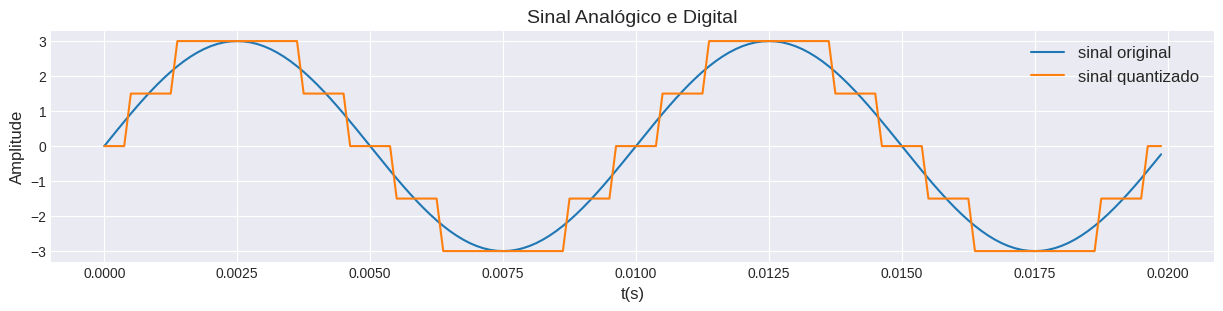

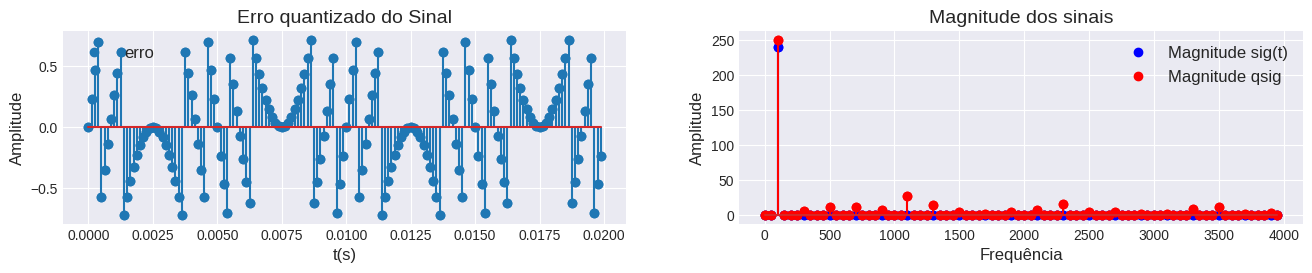

In [ ]:
# Configurando os gráficos.
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(15, 3))
plt.plot(t, sig(t), label='sinal original')
plt.plot(t, qsig, label='sinal quantizado')
plt.xlabel('t(s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Sinal Analógico e Digital', fontsize=14)
plt.legend(fontsize=12)


fig, axis = plt.subplots(1, 2, figsize = (16,2.5))

axis[0].plot(t, erro, "o", label='erro')
axis[0].stem(t, erro)
axis[0].set_xlabel('t(s)', fontsize=12)
axis[0].set_ylabel('Amplitude', fontsize=12)
axis[0].set_title('Erro quantizado do Sinal', fontsize=14)
axis[0].legend(fontsize=12)

axis[1].plot(freq[:len(t)//2], np.abs(sig_fft[:len(t)//2]), "o", color = "blue", label='Magnitude sig(t)')
axis[1].stem(freq[:len(t)//2], np.abs(sig_fft[:len(t)//2]), linefmt='b-', markerfmt='bo')
axis[1].plot(freq[:len(t)//2], np.abs(qsig_fft[:len(t)//2]), "o", color = "red", label='Magnitude qsig')
axis[1].stem(freq[:len(t)//2], np.abs(qsig_fft[:len(t)//2]), linefmt='r-', markerfmt='ro')
axis[1].set_xlabel('Frequência', fontsize=12)
axis[1].set_ylabel('Amplitude', fontsize=12)
axis[1].set_title('Magnitude dos sinais', fontsize=14)
axis[1].legend(fontsize=12)

plt.show()

### Relação sinal ruído

No processo de quantização o sinal de amostragem pode perder seu valor em relação ao valor de amplitude do sinal original dependendo da quantidade de bits que escolhemos, assim sendo representado por seu valor arredondado, por isso que usamos a função `round`.

A relação sinal ruído __(SNR)__ é defenido como a razão da potência do sinal original e a potência do erro quantizado, expressa geralmente em decibeis (dB).
$$SNR_{db} = 10log_{10}\left (\frac{P_s}{P_e}\right) = 20log_{10}\left (\frac{RMS_s}{RMS_e}\right)$$
A potência é o valor de RMS elevado ao quadrado.

In [ ]:
def x(rms):
  sum = 0
  for i in range(len(rms)):
    sum += rms[i]**2
  return sum

for i in range(len(erro)):
    if erro[i] < -1 or erro[i] >= 1:
        print('Erro muito grande, tente aumentar o número de bits!')

pot_sig = x(sig(t))
pot_erro = x(erro)

snr_db = 10*np.log10(pot_sig/pot_erro)
print("O valor de SNR em dB:", snr_db)

O valor de SNR em dB: 14.590353893822028


### Recuperação de Sinais Analógicos a partir de Sinais Amostrados
---
Abordamos a recuperação de um sinal analógico a partir de sua versão amostrada. Dependendo da frequência de amostragem $f_s$ em relação ao dobro da frequência máxima do sinal $2f_{max}$, temos diferentes cenários de recuperação:

+ $f_s = 2f_max:$ Esse é o caso ideal onde a frequência de Nyquist é igual à frequência máxima do sinal, mas é impraticável devido à necessidade de um filtro passa-baixa ideal.

+ $f_s > 2f_max:$ Há uma separação entre as bordas de frequência, portanto um filtro passa-baixa prático consegue rejeitar imagens espectrais e recuperar o espectro do sinal original.

+ $f_s < 2f_max:$ A condição de Nyquist é violada, gerando aliasing, ou seja, distorções espectrais que comprometem o sinal recuperado. Mesmo aplicando um filtro passa-baixa ideal, ainda possui componentes que contém o ruído, portanto o sinal analógico recuperado é irremediavelmente distorcido.

### Considerações praticas para amostragem de sinal: FILTRAGEM ANTI-ALIASING
---

Na prática, o sinal analógico a ser digitalizado pode conter outros componentes de frequência cujas frequências são maiores do que a frequência de dobramento, como ruído de alta frequência. A filtragem anti-aliasing é fundamental em sistemas de amostragem de sinais para evitar o fenômeno do aliasing. Isso pode ser causado por componentes de alta frequência, como ruídos e interferências, presentes no sinal analógico original.

Para evitar o aliasing, utiliza-se um filtro anti-aliasing passa-baixo antes da conversão de analógico para digital (A/D). Esse filtro é projetado para atenuar componentes de frequência que estão acima da frequência de Nyquist, garantindo que apenas as frequências desejadas sejam amostradas.

No entanto, devido à atenuação não ideal da resposta em frequência de magnitude do filtro passa-baixo, uma pequena quantidade de ruído de aliasing pode ainda surgir na banda base. Esse ruído residual pode ser minimizado escolhendo um filtro de ordem superior, que tem uma resposta de corte mais acentuada, ou aumentando a taxa de amostragem, o que eleva a frequência de Nyquist e, portanto, afasta as réplicas espectrais.

Filtros Butterworth são frequentemente utilizados para filtragem anti-aliasing devido à sua resposta de frequência plana na banda passante e transição suave na região de corte, o que minimiza distorções na banda útil do sinal. No entanto, é importante considerar que os filtros analógicos possuem limitações físicas, como atraso de fase e possíveis distorções, exigindo um planejamento cuidadoso para garantir que o sinal digital resultante seja uma representação fiel do original.

### Aplicação de Filtragem em sinais
---
Filtros são sistemas que permitem a passagem de certas faixas de frequência enquanto atenuam ou bloqueiam outras. Os tipos mais comuns incluem passa-baixa, passa-alta, passa-banda e rejeita-banda.

+ __Filtro Passa-Baixa:__ Permite a passagem de frequências abaixo de uma frequência de corte e atenua as frequências acima dela. No exemplo abaixo, representando um sinal ruidoso digitalizado obtido da digitalização de tensões analógicas (saída do sensor) contendo sinal de baixa frequência útil e ruído que ocupam toda a faixa de frequência e iremos usar um filtro passa-baixa para preservar o sinal de 50 Hz e atenuar o ruído de 300 Hz. Como nosso sinal útil contém componentes de baixa frequência, os componentes de alta frequência acima
da frequência de corte do nosso sinal útil são considerados ruído, que pode ser removido usando um filtro passa-baixa digital.

### Exemplo 1:
---
Para gerar um código que simule a situação apresentada, onde temos um sinal ruidoso e aplicamos um filtro passa-baixa para remover o ruído, podemos seguir os seguintes passos:

- Criar um sinal útil de baixa frequência (senoidal).
- Adicionar ruído de alta frequência para simular o sinal ruidoso.
- Aplicar um filtro passa-baixa digital para remover o ruído e recuperar o sinal útil.

In [ ]:
# Parâmetros do sinal
fs = 5000
t = np.linspace(0, 0.1, int(0.1 * fs), endpoint=False)
f_signal = 50
f_noise = 300

# Gerando o sinal útil e o ruído
signal = np.sin(2 * np.pi * f_signal * t)
noise = 0.5 * np.sin(2 * np.pi * f_noise * t)
noisy_signal = signal + noise

# Configurando o filtro passa-baixa
# Definindo frequencia e ordem do filtro.
cutoff = 100
order = 4

# Função para criar filtro passa-baixa Butterworth
def butter_lowpass(cutoff, fs, order=5):
  # Definindo afrequencia de Nyquist e normalizando a freq. do filtro.
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

# Função para aplicar o filtro
def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

# Aplicando o filtro ao sinal ruidoso
filtered_signal = butter_lowpass_filter(noisy_signal, cutoff, fs, order)

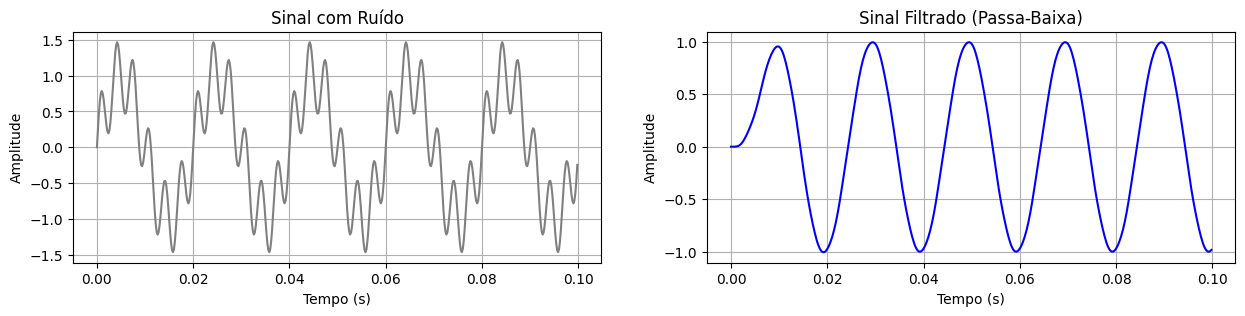

In [ ]:
# Plotando os sinais
fig, axs = plt.subplots(1, 2, figsize=(15, 3))

# Sinal ruidoso
axs[0].plot(t, noisy_signal, color="gray")
axs[0].set_title("Sinal com Ruído")
axs[0].set_xlabel("Tempo (s)")
axs[0].set_ylabel("Amplitude")
axs[0].grid()

# Sinal filtrado
axs[1].plot(t, filtered_signal, color="blue")
axs[1].set_title("Sinal Filtrado (Passa-Baixa)")
axs[1].set_xlabel("Tempo (s)")
axs[1].set_ylabel("Amplitude")
axs[1].grid()

plt.show()

### Conversão Analógica para Digital, Conversão Digital para Analógica e Quantização
---
Durante o processo de conversão analógico-digital (ADC), as amplitudes do sinal analógico possuem precisão teórica infinita. Para representar esses valores no domínio digital, com precisão finita, é necessário realizar a quantização. Esse processo converte a amplitude contínua do sinal analógico em valores discretos, adequados para processamento digital.

O erro introduzido nesse processo é denominado erro de quantização, que é definido como a diferença entre a tensão analógica original (*$v_{in}$*) e a tensão digital recuperada (*$v_o$*). Matematicamente, esse erro pode ser expresso como:
$$Erro \ de \ Quantização = v_o - v_{in}$$

__Processo de Quantização__

A quantização transforma uma tensão analógica com precisão infinita em valores digitais com precisão limitada. Por exemplo, em um sistema com um processador digital de 3 bits, o sinal analógico é representado por apenas 8 níveis diferentes (correspondentes a $2^3 = 8$).

Existem dois tipos principais de quantizadores:

*Quantizador Unipolar:* Utilizado para sinais analógicos com amplitude variando entre 0 e uma tensão de referência positiva ($V_{ref}$).

*Quantizador Bipolar:* Projetado para sinais que variam entre uma referência negativa ($-V_{ref}$) e uma referência positiva ($+V_{ref}$).

+ A resolução do quantizador é definida como a menor diferença de tensão que pode ser detectada entre dois níveis consecutivos, sendo dada por:
$$Δ = \frac{(x_{max} - x_{min})}{2^{Nb}}$$
onde Nb é o número de bits do sistema digital, e *$x_{max}$* e *$x_{min}$* são os valores máximo e mínimo, respectivamente, do sinal de entrada analógico x.

$$i = round\left (\frac{x - x_{min}}{Δ}\right)$$
$$x_q = x_{min} + i.Δ$$

A precisão do processo de quantização depende diretamente do número de bits disponíveis no ADC. Um número maior de bits permite representar o sinal analógico com maior fidelidade, reduzindo o erro de quantização, porém aumenta a complexidade e o custo do sistema. Por outro lado, uma quantização com poucos bits pode introduzir ruídos perceptíveis no sinal digitalizado.

Após a quantização do sinal de entrada $x(𝑡)$, o ADC gera códigos binários que são processados pelo conversor digital-analógico (DAC). O DAC utiliza um circuito de retenção de ordem zero (*zero-order hold*) para converter esses códigos em um sinal analógico discreto. Esse sinal, denominado *sample-and-hold*, apresenta uma forma escalonada.

Para suavizar o sinal, aplica-se um filtro anti-imagem, que elimina componentes de alta frequência geradas no processo de amostragem. Após essa filtragem, obtém-se um sinal analógico contínuo, que se aproxima do sinal original. Esse processo é fundamental para sistemas que exigem a conversão de dados digitais em sinais analógicos, como em áudio e comunicação.

### Exemplo 2:
---
Neste exemplo demonstra a quantização uniforme com base no número de bits especificado, onde o valor de entrada é quantizado em níveis discretos. A função de quantização também recupera o valor quantizado.

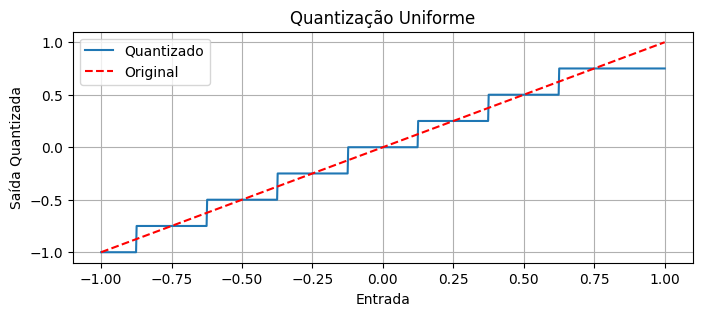

In [ ]:
def quantizar(NoBits, Xmin, Xmax, valor):
    L = 2 ** NoBits
    delta = (Xmax - Xmin) / L
    I = np.round((valor - Xmin) / delta)
    I = np.clip(I, 0, L - 1)
    return Xmin + I * delta

# Parâmetros de quantização
NoBits = 3
Xmin = -1
Xmax = 1
valor = np.linspace(Xmin, Xmax, 1000)

# Quantização
valor_quantizado = quantizar(NoBits, Xmin, Xmax, valor)

# Conversão para NumPy para visualização
#valor_npu = np.asnumpy(valor)
#valor_quantizado_npu = np.asnumpy(valor_quantizado)

# Plotando a quantização
plt.figure(figsize=(8, 3))
plt.plot(valor, valor_quantizado, label="Quantizado")
plt.plot(valor, valor, 'r--', label="Original")
plt.title("Quantização Uniforme")
plt.xlabel("Entrada")
plt.ylabel("Saída Quantizada")
plt.legend()
plt.grid()
plt.show()


### Referências
---
1. **Juan**. *conceito amostragem e quantização*. Disponível em: [https://www.youtube.com/watch?v=5jpacFCD34k](https://www.youtube.com/watch?v=5jpacFCD34k). Acessado em: 31 de outubro de 2024
2. **Leandro Manso**. *Efeito do Erro de Quantização dos ADCs*. Disponível em: [https://www.youtube.com/watch?v=uwtjkeb9Mk8](https://www.youtube.com/watch?v=uwtjkeb9Mk8). Acessado em: 31 de outubro de 2024
3. **Francinildo Figueiredo**. *Desempenho de Equalizadores adaptativos*. Disponível em: [https://github.com/edsonportosilva/Repositorio-PIBIC-2022](https://github.com/edsonportosilva/Repositorio-PIBIC-2022). Acessado em: 31 de outubro de 2024
4. **Tan, L., & Jiang, J.**. *Digital Signal Processing: Fundamentals and Applications*. 3ª Edição. AP, 2019